# Futures & Forwards Pricing
## 1. Forward Price - Cost of Carry Model

In [5]:
# On importe ce dont on a besoin

import numpy as np 
import matplotlib.pyplot as plt



In [6]:
# On fixe les paramètres 

S = 100 # prix spot 
r = 0.05 # rf
q = 0.02 # taux de dividende 
T = 1 # maturité en année 

print(f"Spot Price  (S) : {S}€")
print(f"Risk-free   (r) : {r*100}%")
print(f"Dividend    (q) : {q*100}%")
print(f"Maturity    (T) : {T} year")


Spot Price  (S) : 100€
Risk-free   (r) : 5.0%
Dividend    (q) : 2.0%
Maturity    (T) : 1 year


In [7]:
# Calcule du prix forward : 

def forward_price(S, r, q, T) : 
    F = S * np.exp((r-q)*T)
    return round(F,2)

F = forward_price(S, r,q ,T)

print("=" * 40)
print("      FORWARD PRICING SUMMARY")
print("=" * 40)
print(f"Spot Price     (S) : {S}€")
print(f"Forward Price  (F) : {F}€")
print(f"Cost of Carry      : {round((F-S), 2)}€")
print("=" * 40)


      FORWARD PRICING SUMMARY
Spot Price     (S) : 100€
Forward Price  (F) : 103.05€
Cost of Carry      : 3.05€


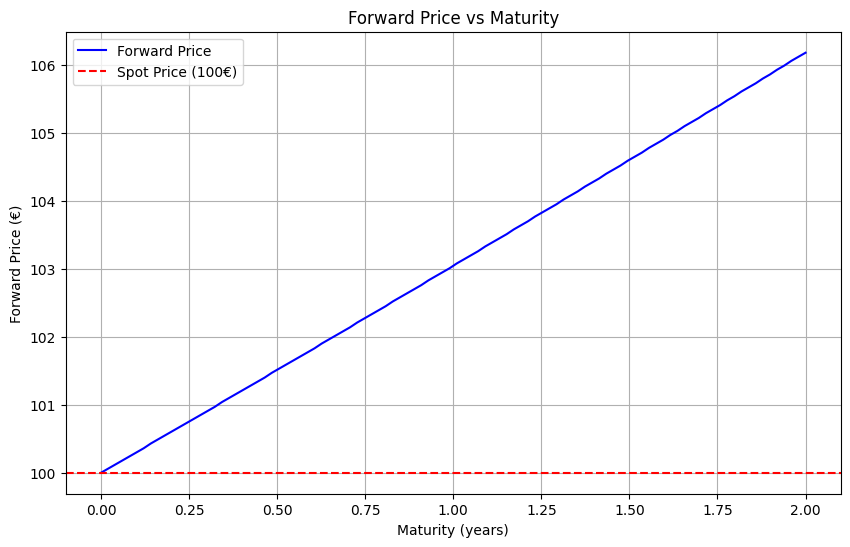

In [8]:
# on s'intéresse au prix forward vs. maturité

maturities = np.linspace(0,2,100)

# On calcule le prix forward pour chaque maturité 
forward_prices = [forward_price(S, r, q, t) for t in maturities]

# graph 
plt.figure(figsize=(10, 6))
plt.plot(maturities, forward_prices, color="blue", label="Forward Price")
plt.axhline(y=S, color="red", linestyle="--", label=f"Spot Price ({S}€)")
plt.title("Forward Price vs Maturity")
plt.xlabel("Maturity (years)")
plt.ylabel("Forward Price (€)")
plt.legend()
plt.grid(True)
plt.show()

## 2. Futures vs Forwards - Les principales différences

In [9]:
# On regarde Futures vs Forwards 

# même formule pour le prix mais différent dans la pratique 
F_forward = forward_price(S, r, q, T)

F_futures = forward_price(S, r, q, T)

print("=" * 50)
print("      FUTURES vs FORWARDS COMPARISON")
print("=" * 50)
print(f"Forward Price        : {F_forward}€")
print(f"Futures Price        : {F_futures}€")
print("-" * 50)
print("Key Differences:")
print("  Forwards : OTC, customizable, settled at maturity")
print("  Futures  : Exchange-traded, standardized, daily MTM")
print("=" * 50)

      FUTURES vs FORWARDS COMPARISON
Forward Price        : 103.05€
Futures Price        : 103.05€
--------------------------------------------------
Key Differences:
  Forwards : OTC, customizable, settled at maturity
  Futures  : Exchange-traded, standardized, daily MTM


### Key Differences
| | Forwards | Futures |
|---|---|---|
| **Traded** | OTC (gré à gré) | Exchange (bourse) |
| **Settlement** | At maturity | Daily Mark-to-Market |
| **Customization** | Full | Standardized |
| **Counterparty Risk** | High | Low (clearing house) |
| **Pricing** | Identical formula | Identical formula |

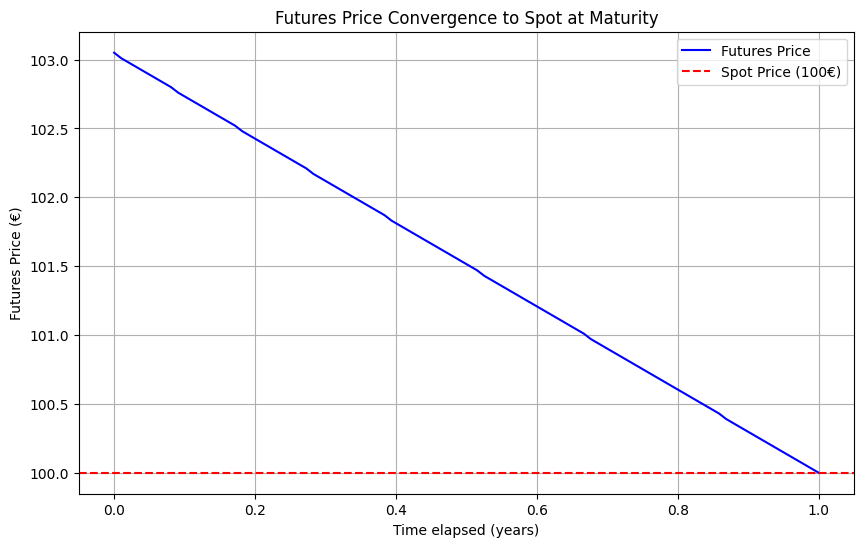

In [10]:
# Convergence du futures vers le spot
time_to_maturity = np.linspace(1, 0, 100)  # De 1 an à 0
futures_prices = [forward_price(S, r, q, t) for t in time_to_maturity]

plt.figure(figsize=(10, 6))
plt.plot(np.linspace(0, 1, 100), futures_prices, color="blue", label="Futures Price")
plt.axhline(y=S, color="red", linestyle="--", label=f"Spot Price ({S}€)")
plt.title("Futures Price Convergence to Spot at Maturity")
plt.xlabel("Time elapsed (years)")
plt.ylabel("Futures Price (€)")
plt.legend()
plt.grid(True)
plt.show()

## 3. Forward Price by Asset Class

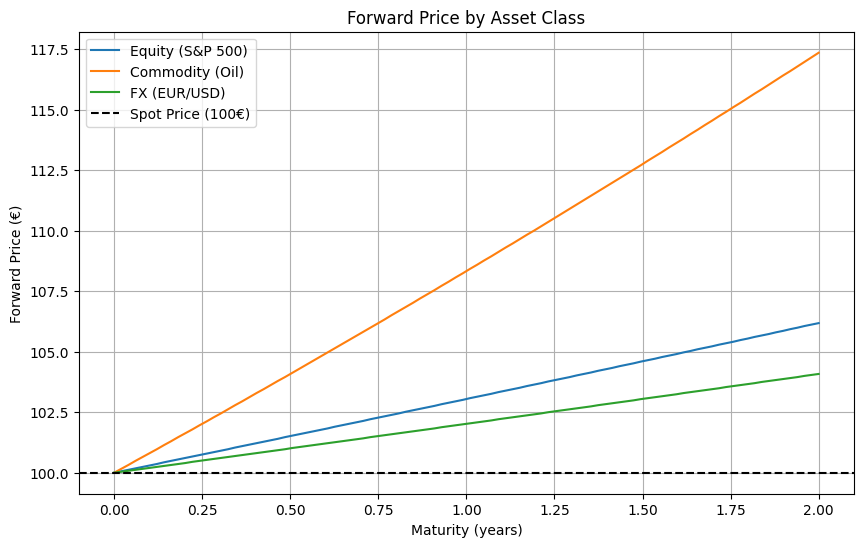

In [ ]:
# Selon différentes classes d'actifs
assets = {
    "Equity (S&P 500)" : {"S": 100, "r": 0.05, "q": 0.02},  # q = dividend yield
    "Commodity (Oil)"  : {"S": 100, "r": 0.05, "q": -0.03}, # q = cout de stockage (negative)
    "FX (EUR/USD)"     : {"S": 100, "r": 0.05, "q": 0.03},  # q = foreign interest rate
}

maturities = np.linspace(0, 2, 100)

plt.figure(figsize=(10, 6))

for asset, params in assets.items():
    prices = [forward_price(params["S"], params["r"], params["q"], t) for t in maturities]
    plt.plot(maturities, prices, label=asset)

plt.axhline(y=100, color="black", linestyle="--", label="Spot Price (100€)")
plt.title("Forward Price by Asset Class")
plt.xlabel("Maturity (years)")
plt.ylabel("Forward Price (€)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Résumé final de ce qu'on obtient : 

print("=" * 50)
print("       FUTURES & FORWARDS PRICING SUMMARY")
print("=" * 50)
print(f"Spot Price         (S) : {S}€")
print(f"Risk-free Rate     (r) : {r*100}%")
print(f"Dividend Yield     (q) : {q*100}%")
print(f"Maturity           (T) : {T} year")
print("-" * 50)
print(f"Forward Price      (F) : {F_forward}€")
print(f"Futures Price      (F) : {F_futures}€")
print(f"Cost of Carry          : {round(F_forward - S, 2)}€")
print("-" * 50)
print("Asset Class Comparison at T=1:")
for asset, params in assets.items():
    F = forward_price(params["S"], params["r"], params["q"], 1)
    print(f"  {asset:20} : {F}€")
print("=" * 50)

       FUTURES & FORWARDS PRICING SUMMARY
Spot Price         (S) : 100€
Risk-free Rate     (r) : 5.0%
Dividend Yield     (q) : 2.0%
Maturity           (T) : 1 year
--------------------------------------------------
Forward Price      (F) : 103.05€
Futures Price      (F) : 103.05€
Cost of Carry          : 3.05€
--------------------------------------------------
Asset Class Comparison at T=1:
  Equity (S&P 500)     : 103.05€
  Commodity (Oil)      : 108.33€
  FX (EUR/USD)         : 102.02€
